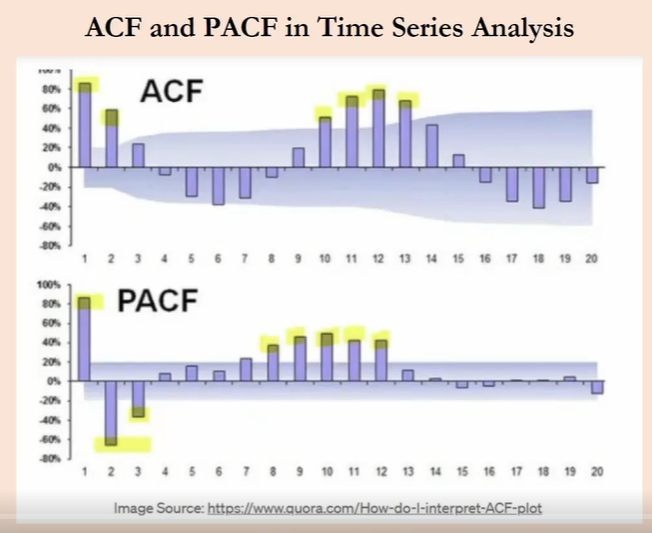

## ACF and PACF in Time Series Analysis

When working with time series data, it is often useful to analyze the autocorrelation of the data to understand the patterns and dependencies between time steps.

Two common tools for this analysis are the **Autocorrelation Function (ACF)** and the **Partial Autocorrelation Function (PACF)**.

**Definition**

**Autocorrelation (ACF):** Measures how a time series is related to its past values over different lags.

ACF plots show the correlation between a time series and lagged versions of itself. The ACF plot can be used to identify the number of lags that are needed for a time series model.

For example, if the ACF plot shows a strong correlation between the time series and its lag-1, lag-2, and lag-3 values, then a time series model that includes these lags would likely be a good fit.

**PACF : Definition**

**Partial Autocorrelation (PACF):** Measures the correlation between a time series and its past values after removing the influence of intermediate lags.

PACF plots, on the other hand, show the correlation between a time series and its lagged values, after accounting for the correlations at shorter lags. This can be useful for identifying the most important lags to include in a time series model, as well as for identifying the presence of seasonal patterns in the data.

**Concept**

* A lag is the time difference between observations (e.g., Lag 1 = previous month, Lag 2 = two months ago).
* ACF plot $\rightarrow$ shows correlation for all lags, including indirect effects.
* PACF plot $\rightarrow$ shows only the *direct* effect of a lag on the current value.
* **Purpose in ARIMA:**
* PACF is used to identify the AR ($p$) term.
* ACF is used to identify the MA ($q$) term.



**Real-world analogy**

If you want to know how much your exam score was influenced by last weeks study time.

* ACF looks at last week *and* all the weeks before (combined effect).
* PACF isolates just last week's effect, ignoring the influence of earlier weeks.

## ACF vs PACF

### ACF (autocorrelation function)

"How similar is the series to a shifted copy of itself?"

* ACF at lag 1: correlation between $x_t$ and $x_{t-1}$
* ACF at lag 2: correlation between $x_t$ and $x_{t-2}$, etc.
It includes direct + indirect effects (e.g., lag 2 includes the pathway through lag 1).

PACF (partial autocorrelation function)

"How similar is the series to a shifted copy after removing the in-between lags?"

* PACF at lag 2 removes the influence of lag 1 from both sides, leaving the direct link between $x_t$ and $x_{t-2}$.

**Example Take 6 monthly values : $x = [3, 4, 2, 5, 1, 3]$**

**Step 1 — Mean and deviations**

* Mean $\bar{x} = (3 + 4 + 2 + 5 + 1 + 3) / 6 = 3$
* Deviations $d = x - \bar{x} = [0, 1, -1, 2, -2, 0]$

**Step 2 — Denominator for correlations**

* $\sum d_t^2 = 0^2 + 1^2 + (-1)^2 + 2^2 + (-2)^2 + 0^2 = 10$

**ACF at lag 1 (corr between $x_t$ and $x_{t-1}$)**

* Numerator = $\sum d_t d_{t-1}$ for $t = 2$ to $6$:
* $1 \cdot 0 = 0$
* $(-1) \cdot 1 = -1$
* $2 \cdot (-1) = -2$
* $(-2) \cdot 2 = -4$
* $0 \cdot (-2) = 0$
* Sum = $-7$



$$\rho_1 = \frac{-7}{10} = -0.7$$

**Interpretation**: strong negative relationship month-to-month (values tend to bounce up then down).

Refer python program `ACF_PACF_Calc` in parallel with this maths calculation.

* Mean $\bar{x} = (3 + 4 + 2 + 5 + 1 + 3) / 6 = 3$
* Deviations $d = x - \bar{x} = [0, 1, -1, 2, -2, 0]$

**Interpretation**: strong negative relationship month-to-month (values tend to bounce up then down).

**ACF at lag 2 (corr between $x_t$ and $x_{t-2}$)**

Pairs for $t = 3$ to $6$:

* $(-1) \cdot 0 = 0$
* $2 \cdot 1 = 2$
* $(-2) \cdot (-1) = 2$
* $0 \cdot 2 = 0$
* Sum = $4$

$$\rho_2 = \frac{4}{10} = 0.4$$

**Interpretation**: once you skip one month, there's a **positive** association again (typical of oscillating series).

**PACF at lag 1**

For lag 1, PACF equals ACF:

$$\phi_{11} = \rho_1 = -0.7$$

**PACF at lag 2 (remove the effect of lag 1)**

For $k = 2$, the partial autocorrelation has a neat closed form:

$$\phi_{22} = \frac{\rho_2 - \rho_1^2}{1 - \rho_1^2} = \frac{0.4 - 0.49}{1 - 0.49} = \frac{-0.09}{0.51} \approx -0.176$$

**Interpretation**: the direct link between $x_t$ and $x_{t-2}$ (after removing lag-1 effects) is **mildly negative**, even though the raw ACF at lag 2 was $+0.4$. This is the whole point of PACF: strip away indirect paths (through lag 1) to see what's directly connected.

* Lag-1 $\text{ACF} = -0.7$ means consecutive months move in opposite directions on average.

**ARIMA Model Building**

**Definition**

* **ARIMA** stands for **AutoRegressive Integrated Moving Average**.
* It's a forecasting model that combines:
* **AR ($p$)** $\rightarrow$ Autoregressive terms: Past values predict current value.
* **I ($d$)** $\rightarrow$ Integrated: Differencing to make the series stationary.
* **MA ($q$)** $\rightarrow$ Moving Average terms: Past forecast errors predict current value.



---

**Concept**

* ARIMA is suitable for **non-seasonal** time series that can be made stationary.